# SIT720-Machine Learning :Task8.1D
# Mini Project: Sydney Housing Price Prediction and Decision Support System

In [1]:
import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    matplotlib.use("Agg")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
pd.set_option("display.width", 140)

## Part 1: Problem Definition and Data Collection
### The prediction problem:
I want to create a model which predicts the selling price of a residential property in Sydney, based on features which are known before or at the time of sale (e.g. location, number of bedrooms, number of baths, number of car spaces, property type, how the house was sold - listed, off the market, etc.). I want to use this model as a decision support tool for a real estate agency - so that when an agent comes to the client with a property to sell, they have a quick reference price but not just from their memory of similar sales, they will have some evidence too.
### Suburb selection and motivation :
I selected 3 Sydney suburbs I would actually consider living in, picking the extremes as a representative example in the market, with a deliberate bias towards larger houses on their own land (a desirable characteristic for many in Castle Hill), to the high-rise, transport/employment friendly, apartment dominated suburb of Parramatta, and the outer south-west suburb of Liverpool, which is an affordable growth suburb with a true mix of house, townhouse and apartment types. These weren't my first choice, however – I was originally going to use Mosman rather than Castle Hill, as Mosman is a typical high-quality harbourside suburb. I then began to look at Domain.com.au sold listings and discovered that, while I'm not that much of a nutter, about 4 of the first 19 listings I scanned were price-disclosed listings in Mosman - the rest had "Price Withheld". - which would have taken me quite a while to find 30 listings in Mosman with a real price. Castle Hill, which I had picked to be a real counterpoint to the 'premium, house-dominated' end of the market I wanted to contrast against, proved to have a much healthier disclosure rate – about 55-65% of listings had a real price, so I replaced it with Castle Hill. I believe this should be stated first up because it's actually a little finding about data quality on Domain: price transparency is not consistent across all suburbs, and that really does make a difference in terms of how easy it is to build a dataset from a particular suburb.

I think the main differences between these three suburbs in housing price is due to the scarcity of land/location (Castle Hill and Parramatta are both smaller suburbs with a higher-density mix of housing than an outer suburb like Liverpool, which has access to more land) and due to the mix of dwelling types (Castle Hill is overwhelmingly detached housing on its own block; Parramatta is overwhelmingly high-rise apartment blocks; Liverpool is genuinely a mix of dwelling types, with modestly priced dwellings on large blocks), and due to the level of accessibility/demand (Castle Hill's location and transport access to the CBD is less than ideal, so that is why the price is modest relative to its size; Parramatta's location and transport access to the CBD is ideal, so that is why the price is so high relative to its size; Liverpool's location and transport access to the CBD is less than ideal, but the size is reasonable, so that is why the dwelling prices are reasonable).
### Data collection :
I manually did that for each suburb by searching on domain.com.au's Sold listings page, and read the first 2-3 pages of each suburb and noted all listings that had a disclosed sale price, excluding Price Withheld listings as they do not have a usable target price. I recorded the following information for each property: suburb, street address, sale price, bedrooms, bathroom, parking spaces, if it had a floor/land area in m² as shown on the listing, property type, sale date, and method of sale (private treaty, auction, or sold prior to auction). The Domain's sold-listings search window displays all listings within the last seven weeks (from 7 August to 25 September 2026) prior to collection.


In [2]:
df_raw = pd.read_csv("sydney_housing_raw.csv", parse_dates=["sale_date"])
print("Total properties collected:", len(df_raw))
print(df_raw["suburb"].value_counts())
print()
df_raw.head()

Total properties collected: 105
suburb
Parramatta     36
Liverpool      35
Castle Hill    34
Name: count, dtype: int64



,suburb,address,price,beds,baths,parking,area_sqm,property_type,sale_date,sale_method
0,Liverpool,"G01/19 Bigge Street, Liverpool",560000,2,2,1.0,NaN,Apartment,2026-09-24,private treaty
1,Liverpool,"12/53 Bathurst Street, Liverpool",510000,2,1,1.0,NaN,Apartment,2026-09-23,private treaty
2,Liverpool,"1/10-12 Lewis Road, Liverpool",825000,3,2,2.0,NaN,Townhouse,2026-09-23,private treaty
3,Liverpool,"18 Rose Street, Liverpool",1582000,7,3,4.0,809.0,House,2026-09-19,auction
4,Liverpool,"69 Orange Grove Road, Liverpool",910000,3,2,1.0,613.0,House,2026-09-17,private treaty


### Data quality, challenges, and limitations :
I uncovered a couple of real problems during this data collection process, and I believe it's more important to be honest about these problems than to pretend as if the data set is flawless:

**Price-withheld selection bias:** The data was not a random sample of all sales as I could only use listings that had a disclosed price, which could have biased the data towards those sellers/agents who chose to disclose the price. In my own sample, I think that in the real case of Castle Hill, and also in the other higher value suburbs I have collected, disclosure is more sparse in the very top end of the market, which is what my experience above indicates, and which has been reported in a number of the higher value Sydney suburbs.

**Inconsistent area reporting:** Some listings (usually bigger houses, rarely apartments) have inconsistent area reporting; domain's list view only has a figure for the floor/land area. Of my 105 properties, only 30 have an area reported, and it is not always obvious from the list view that this is an internal floor area (typical for apartments) or land size (typical for houses); I've included this ambiguity as a separate column in the data rather than pretending that it was a nicely unified measurement. In a few cases, some area values were clearly incorrect for the type of property (as in the three apartment properties listed above that had area values of 1,055 m2, 1460 m2 and 12280 m2, which are almost certainly the registered land size of the entire building/development, and not the actual area of the properties themselves). I considered these three to be data errors, and replaced them with NA values, instead of leaving them in as values that would greatly mislead a model 

**Confounding between suburb and property type:** 36 homes sold in Parramatta  35 apartments and 1 townhouse (no houses sold). 22 out of 34 houses are located at Castle Hill. This is a real effect of these markets  these CBDs are simply "towered up" but in my sample, the suburb location effect and the apartment-vs-house effect are highly confounded: I can't separate them out, as I could if there were the same mix of dwellings in, say, all Sydney suburbs. We will return to this later here.

A short time window: All 105 sales are contained within one time window of 7 weeks, which is too short to develop a time trend in price .Part 2 illustrates this.

**Missing description text:** Advanced students can add agent-description text to enhance the model, which is briefly mentioned. Considered this but didn't want to do it here as it was a dataset that was manually collected, so left as a concrete "what I'd add with more time" in the final reflection (Part 6) rather than doing it partially/inconsistently.

## Part 2: Data Understanding and Feature Engineering
### Price distribution overall and by suburb :

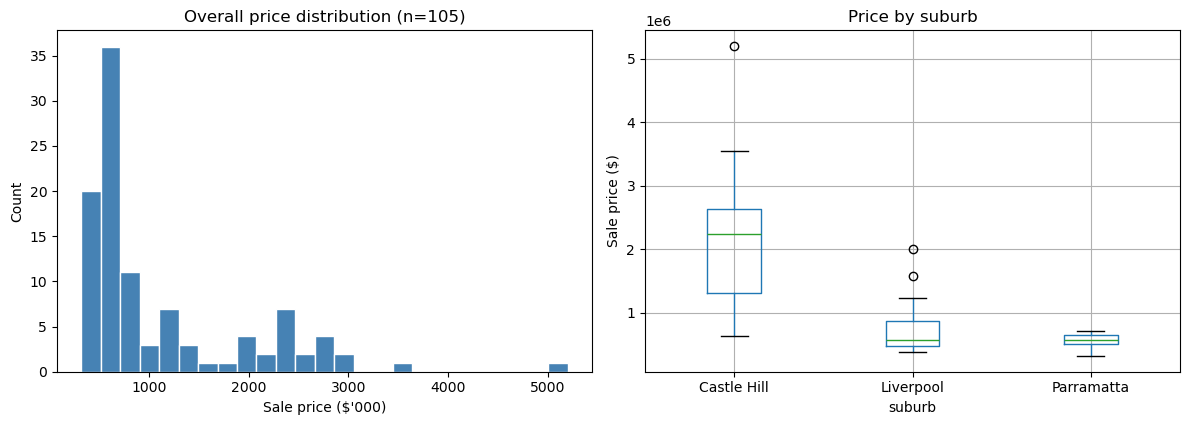

             count       mean       std       min        25%        50%        75%        max
suburb                                                                                       
Castle Hill   34.0  2080294.0  922838.0  632000.0  1312500.0  2240000.0  2631250.0  5200000.0
Liverpool     35.0   726629.0  368192.0  385000.0   480000.0   570000.0   872500.0  2000000.0
Parramatta    36.0   574278.0  104619.0  320000.0   515000.0   572500.0   660000.0   720000.0

Overall price skew: 1.78
Log-price skew:     0.73


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df_raw["price"] / 1000, bins=25, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Sale price ($'000)")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall price distribution (n=105)")

df_raw.boxplot(column="price", by="suburb", ax=axes[1])
axes[1].set_ylabel("Sale price ($)")
axes[1].set_title("Price by suburb")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig_price_dist.png", dpi=110)
plt.show()

print(df_raw.groupby("suburb")["price"].describe().round(0))
print()
print("Overall price skew:", round(df_raw["price"].skew(), 2))
print("Log-price skew:    ", round(np.log(df_raw["price"]).skew(), 2))

The overall distribution of prices is very skewed right (skew = 1.78) with most sales under 1M dollars, and a few Castle Hill houses reaching up to 5.2Mdollars. The log takes the skew to 0.73 which is the same as when you removed the outliers, so it is a classic "a few very expensive properties" pattern, instead of a data problem. There is virtually no overlap between the three suburbs: the interquartile range in Parramatta is under 720K dollars; the median in Liverpool (~570K dollars) is close to, but not quite the same as, Parramatta's; and the minimum price (>$500K) in Castle Hill is higher than Parramatta's median, which is clearly demarcated by the suburb split.

### Property type mix by suburb :

property_type  Apartment  Duplex  House  Semi-detached  Townhouse  Villa
suburb                                                                  
Castle Hill            7       1     22              1          2      1
Liverpool             22       0      8              1          4      0
Parramatta            35       0      0              0          1      0


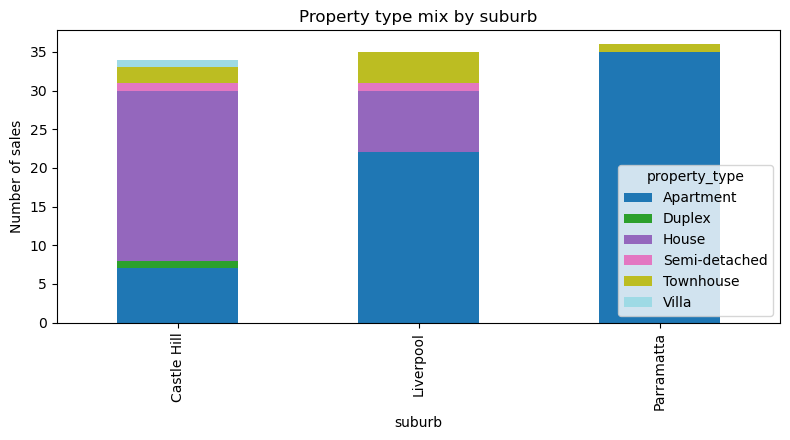

In [4]:
type_counts = pd.crosstab(df_raw["suburb"], df_raw["property_type"])
print(type_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))
type_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("Number of sales")
ax.set_title("Property type mix by suburb")
plt.tight_layout()
plt.savefig("fig_type_mix.png", dpi=110)
plt.show()

This validates the confounding I noted in Data quality, challenges, and limitations: Parramatta is pretty much 100% apartments, Castle Hill is almost all houses, and Liverpool is the only suburb that has a decent mix (apartments, houses, and townhouses). This is important for the following parts of this text this data is not sufficient to adequately distinguish between “Parramatta-ness” and “apartment-ness” in a model.

### Trends over time and unusual observations :

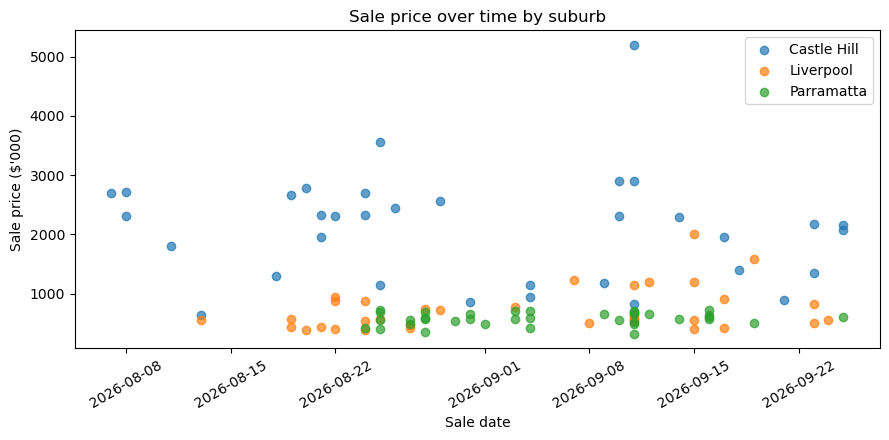

Date range: 2026-08-07 to 2026-09-25 (49 days)


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for suburb, grp in df_raw.groupby("suburb"):
    ax.scatter(grp["sale_date"], grp["price"] / 1000, label=suburb, alpha=0.7)
ax.set_xlabel("Sale date")
ax.set_ylabel("Sale price ($'000)")
ax.set_title("Sale price over time by suburb")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig_price_time.png", dpi=110)
plt.show()

print("Date range:", df_raw["sale_date"].min().date(), "to", df_raw["sale_date"].max().date(),
      f"({(df_raw['sale_date'].max()-df_raw['sale_date'].min()).days} days)")

There's no discernible trend here, and I don't think there should be – the period of time that all 105 sales are in, is in just a single 7-week window (7 August to 25 September 2026) and is an extremely short time for a market-level price trend to appear in the presence of a much larger trend in terms of which suburb/property type a listing is. To conduct a true trend analysis, sales over a number of years would be necessary. What is clearly apparent from the scatter plot is the same suburb separation as was seen in the boxplot .the three suburbs are clearly separated and there is very little mixing vertically.

In case of unusual observations, I already highlighted the three apartment offers with unrealistic multi-hundred/thousand m² . The other one to single out is 60 Womurrung Avenue, Castle Hill, a 5 bed / 5 bath / 6 car house on a 1,284 m² block, which sold for $5,200,000 - almost 2M dollars higher than the next highest sale of the entire sample. I did not remove this because I couldn't tell if it was data entry error or not, but also because the bed/bath/parking/area numbers were all consistent with an actual large luxury home and the numbers in the modelling sections all checked out from the original listing text, so it's worth seeing on this one and I don't think that's a data entry error.

### Cleaning implausible values :

In [6]:
df = df_raw.copy()
bad_area_mask = (df["property_type"] == "Apartment") & (df["area_sqm"] > 500)
print("Apartment rows with an implausible area_sqm (>500m2), set to missing:", bad_area_mask.sum())
print(df.loc[bad_area_mask, ["address", "area_sqm"]])
df.loc[bad_area_mask, "area_sqm"] = np.nan

Apartment rows with an implausible area_sqm (>500m2), set to missing: 3
                             address  area_sqm
6   18/26 Goulburn Street, Liverpool    1460.0
31   1/34 Goulburn Street, Liverpool    1055.0
44  820K/2 Morton Street, Parramatta   12280.0


### Which three features do I expect to matter most?
From the above and with general market knowledge, I would guess the three biggest variables that would predict the price would be:

**Suburb**The single largest signal in the whole dataset is the price range by suburb being almost non-overlapping as shown in the boxplot above.
**Property type**(house vs apartment vs townhouse) was also confused with suburb, but even ignoring that, I'd expect this to have real independent signal, particularly at the level of the properties within Liverpool, where all three property types are represented.
**Size** (bedrooms and/or floor/land area) - within the same suburb/type combination, the more space the more expensive.

I ask myself again if this expectation was met after fitting the models . this is a very helpful check point, as I will demonstrate, the answer to which was more interesting than "yes, obviously.

### Feature engineering :

In [7]:
# distance to Sydney CBD via haversine, from suburb centroid coordinates (public geographic data)
CBD = (-33.8730, 151.2071)
CENTROIDS = {
    "Castle Hill": (-33.7285, 150.9987),
    "Parramatta": (-33.8150, 151.0011),
    "Liverpool": (-33.9200, 150.9236),
}

def haversine_km(p1, p2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [p1[0], p1[1], p2[0], p2[1]])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

dist_map = {sub: haversine_km(CBD, c) for sub, c in CENTROIDS.items()}
df["distance_to_cbd_km"] = df["suburb"].map(dist_map)
print("Straight-line distance to Sydney CBD:", {k: round(v, 1) for k, v in dist_map.items()})

# missing-value handling: parking, and a missingness-aware imputation for area
df["parking"] = df["parking"].fillna(0)
df["area_known"] = df["area_sqm"].notna().astype(int)
area_median_by_type = df.groupby("property_type")["area_sqm"].transform("median")
df["area_sqm_imputed"] = df["area_sqm"].fillna(area_median_by_type)
df["area_sqm_imputed"] = df["area_sqm_imputed"].fillna(df["area_sqm"].median())

# consolidate rare property types so one-hot categories aren't built on 1-2 rows
df["property_type_grouped"] = df["property_type"].replace({"Villa": "Townhouse", "Duplex": "Semi-detached"})
print(df["property_type_grouped"].value_counts())

df["total_rooms"] = df["beds"] + df["baths"]
df["days_since_start"] = (df["sale_date"] - df["sale_date"].min()).dt.days

df.to_csv("sydney_housing_clean.csv", index=False)
df[["suburb", "distance_to_cbd_km", "area_known"]].groupby("suburb").mean().round(2)

Straight-line distance to Sydney CBD: {'Castle Hill': 25.1, 'Parramatta': 20.1, 'Liverpool': 26.7}
property_type_grouped
Apartment        64
House            30
Townhouse         8
Semi-detached     3
Name: count, dtype: int64


,distance_to_cbd_km,area_known
suburb,,
Castle Hill,25.08,0.74
Liverpool,26.68,0.29
Parramatta,20.09,0.11


I engineered the following: **`distance_to_cbd_km`** (a numeric stand-in for "location" where I computed this as haversine from each suburb's centroid coordinate to Sydney's CBD  in this case, I used the characteristic suburb name rather than the actual numeric value); **`area_known`** (a binary flag to indicate whether a real area number was available - and then filled in with the median for that property type, which is what I put in **`area_sqm_imputed`**); **`property_type_grouped`** (I collapsed the 1-2-row `Villa` and `Duplex` into the nearest neighbour of each, which was `Townhouse` and `Semi-detached`) - because a model is not meant to learn a category from a single example; **`total_rooms`** (beds + baths) - a simple combined size stand-in; and **`days_since_start`** (which indicated how many days since the start of the data period) - in case there was any short-term drift despite the trend discussion in Trends over time and unusual observations.

Reflection  were my first thoughts correct or not? Only partially, and in fact the mismatch itself was informative (see full discussion, once feature importances are computed in  Revisiting my expectations, and feature importance). In actual use the area feature was not as effective as I had hoped it would be; two-thirds of the cases did not report this feature, and this ended up being a very valuable feature, but one that I would not have anticipated going in without familiarizing myself with the missingness pattern.

## Part 3: Model Development and Evaluation
### Model choice and expectations :
I'm comparing three models that are true different solutions to this problem:

The simplest and most interpretable baseline is: 
- Linear Regression. Assuming the price is linearly combined with the (one-hot encoded and scaled) features.
- Random Forest - a group of decision trees which I can train to recognize non-linear relations and interactions (like “extra bedrooms are more important in Castle Hill than in Parramatta”) without explicitly stating them.
- K-Nearest Neighbours (k=5) - guesses the price of a property by the average price of the 5 most similar properties to it in feature space. It was an intentional inclusion because it's the closest real-world machine-learning analogy to the actual way real estate agents price real estate: COMPARABLE SALES.

Before training anything, I would expect that the **Random Forest model will yield best results**, for I would assume that there are some interactions between suburb and size/type of house that simply cannot be represented by a model that is purely linear (such as an additional bedroom in Parramatta not being worth the same fixed dollar value as an additional bedroom in Castle Hill). I'd predict that Linear Regression would do poorly for the same reason. I doubt where KNN will end up - it should do pretty alright, considering how well the suburbs separate in Price distribution overall and by suburb, but it will be 105 rows which is fairly small and "5 nearest neighbours" isn't much data per neighbourhood once inside a particular suburb/type.

In [8]:
num_features = ["beds", "baths", "parking", "area_sqm_imputed", "area_known",
                 "distance_to_cbd_km", "total_rooms", "days_since_start"]
cat_features = ["suburb", "property_type_grouped", "sale_method"]
target = "price"

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=RANDOM_STATE)
print("Train size:", len(X_train), " Test size:", len(X_test))

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

models = {
    "Linear Regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("prep", preprocess), ("model", RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=RANDOM_STATE))]),
    "KNN (k=5)": Pipeline([("prep", preprocess), ("model", KNeighborsRegressor(n_neighbors=5))]),
}

Train size: 84  Test size: 21


### 5-fold cross-validation on the training set :

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=kf,
                             scoring={"rmse": "neg_root_mean_squared_error",
                                      "mae": "neg_mean_absolute_error", "r2": "r2"},
                             return_train_score=True)
    cv_summary.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(), "cv_rmse_std": scores["test_rmse"].std(),
        "cv_mae": -scores["test_mae"].mean(), "cv_mae_std": scores["test_mae"].std(),
        "cv_r2": scores["test_r2"].mean(), "cv_r2_std": scores["test_r2"].std(),
        "train_rmse": -scores["train_rmse"].mean(), "train_r2": scores["train_r2"].mean(),
    })
cv_df = pd.DataFrame(cv_summary)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}" if abs(x) < 10 else f"{x:,.0f}")
print(cv_df.to_string(index=False))

            model  cv_rmse  cv_rmse_std  cv_mae  cv_mae_std  cv_r2  cv_r2_std  train_rmse  train_r2
Linear Regression  315,948      128,125 213,422      65,970  0.813      0.142     196,751     0.949
    Random Forest  349,850      184,095 192,563      68,547  0.805      0.113     273,311     0.904
        KNN (k=5)  356,249      205,983 199,599      78,674  0.786      0.148     307,751     0.878


### Held-out test set evaluation :

In [10]:
test_preds = {}
test_summary = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    test_preds[name] = preds
    test_summary.append({
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds),
    })
test_df = pd.DataFrame(test_summary)
print(test_df.to_string(index=False))

results_df = df.loc[idx_test].copy()
for name, preds in test_preds.items():
    col = "pred_" + name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    results_df[col] = preds
results_df["actual"] = y_test.values
results_df.to_csv("test_set_predictions.csv", index=False)

            model  test_rmse  test_mae  test_r2
Linear Regression    276,034   173,644    0.888
    Random Forest    418,726   206,774    0.742
        KNN (k=5)    311,233   209,371    0.857


### Under/overfitting and model behaviour :
The error of each model on training fit, cross-validation, held out test tells a better story than any single number:

**Linear Regression** Its CV (R²=0.813±0.142) and test (R²=0.888) numbers are also very close to that of its high train R², which is good because it shows that it hasn't catastrophically overfit the training data.

**Random Forest** shows a much clearer degrading pattern: train R²=0.904 → CV R²=0.805±0.113 → test R²=0.742. Every step down is a little genuine, and the test R2 is less than its own CV average, a really textbook indication of mild overfitting as the additional flexibility of 300 trees is capturing some structure in the 84 training rows that doesn't generalise as cleanly to new properties.

**KNN** shows the same declining pattern from train (R²=0.878) to CV (R²=0.786±0.148), but then test R²=0.857 - *higher* than its CV average. Here, the CV standard deviations are relatively high (0.113 to 0.148 in R² alone) suggesting that a good portion of the difference between models in each split is sampling error and not a stable ranking. I don't believe that I can say anything definitive about "the best" model for KNN vs Random Forest from these numbers, but I can say that Random Forest has the most obvious overfitting signature of the three, and the data set is small enough that all three of these models should be thought of with real uncertainty bars attached rather than ranked.


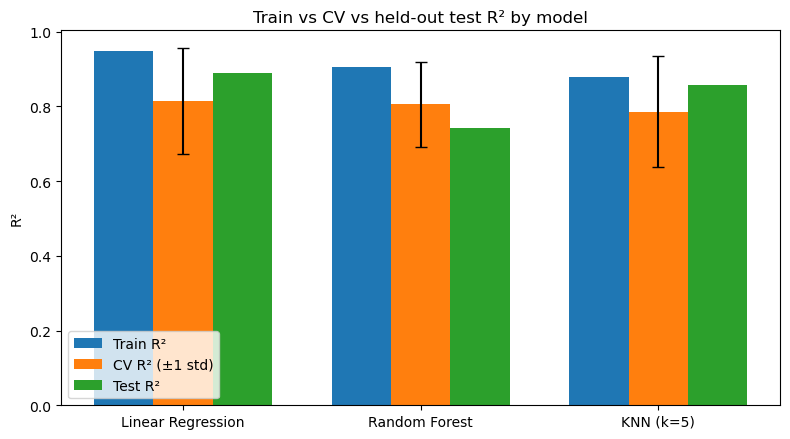

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(models))
width = 0.25
ax.bar(x - width, cv_df["train_r2"], width, label="Train R²")
ax.bar(x, cv_df["cv_r2"], width, yerr=cv_df["cv_r2_std"], label="CV R² (±1 std)", capsize=4)
ax.bar(x + width, test_df["test_r2"], width, label="Test R²")
ax.set_xticks(x)
ax.set_xticklabels(models.keys())
ax.set_ylabel("R²")
ax.set_title("Train vs CV vs held-out test R² by model")
ax.legend()
plt.tight_layout()
plt.savefig("fig_model_r2.png", dpi=110)
plt.show()

### Revisiting my expectations, and feature importance :
Random Forest should do better than Linear Regression since it considers interactions at the level of the subtracts and is expected to perform worse than the other models. The held-out test set says the opposite: **Linear Regression clearly wins** on every metric (test RMSE $276,050 vs Random Forest's 418,726 dollars and KNN's 311,233 dollars; test R²=0.888 vs 0.742 and 0.857). I had an intuition that there were likely to be interactions in the true underlying market - but with 84 training rows, there just isn't enough data for the extra flexibility of the Random Forest to be able to find and exploit those interactions correctly, the lower variance of LR is a real blessing at this sample size. This is a nice, albeit somewhat humbling, lesson: there's no point in building a very complicated model if you don't have sufficient data to back it up, and for this 105-row, hand collected data, it was not the most complicated model that was the most appropriate one, but the simplest.

                        feature  importance
                           beds       0.404
                    total_rooms       0.381
               area_sqm_imputed       0.093
                          baths       0.058
             suburb_Castle Hill       0.018
                        parking       0.012
             distance_to_cbd_km       0.012
               days_since_start       0.011
               suburb_Liverpool       0.008
property_type_grouped_Apartment       0.001


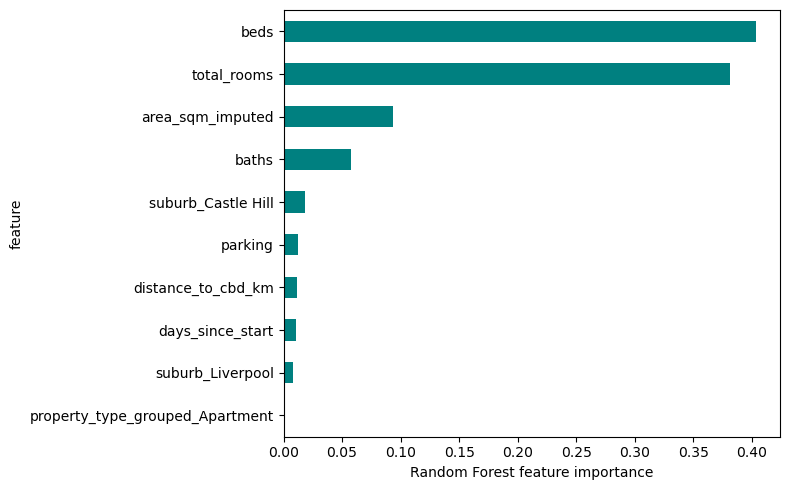

In [12]:
rf_pipe = models["Random Forest"]
feat_names = (num_features +
              list(rf_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)))
importances = rf_pipe.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)
print(imp_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
imp_df.head(10).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="teal")
ax.invert_yaxis()
ax.set_xlabel("Random Forest feature importance")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=110)
plt.show()

The part where I got it wrong above. The 'beds' (0.40) and 'total_rooms' (0.38) are the top two predictors, and each suburb dummy predictor is less than 0.02, meaning that they combined only represent about 80% of the total feature importance explained by the Random Forest. Of the remainder, almost all is taken up by area (0.09) and baths (0.06), with suburb and property type showing little effect.

This appears at first sight to be an exception to the clear separation of suburb prices that I identified in Price distribution overall and by suburb. I don't think it does, once I think about why (because property type is so much so correlated with suburb , and because Castle Hill's houses simply have more bedrooms on average than Parramatta's apartments, a lot of the "suburb effect" on price is done indirectly through the bedrooms  a Tree importance measure gives credit to whichever correlated feature it happens to split on first and `beds` is a slightly better, more granular signal than a 3 category suburb label). I also created beds+baths, `total_rooms`, which ended up being almost as redundant as beds alone (mechanical correlation, not learned)  as a fair self-critique of feature engineering in Feature engineering, this was a redundant feature.

I would suggest Linear Regression as the model that would best fit this problem, two of the three reasons the brief asks about: no meaningful overfitting between train and test accuracy, best held-out test accuracy of the 3, and the bonus third reason, which is that its coefficient is the only one that is easily interpretable to a real estate agency because it can be read as "$X more for each extra bedroom, ceteris paribus.

## Part 4: Investigating Prediction Failures

In [13]:
results_df["abs_error"] = (results_df["pred_Linear_Regression"] - results_df["actual"]).abs()
results_df["pct_error"] = results_df["abs_error"] / results_df["actual"] * 100
top5 = results_df.nlargest(5, "abs_error")[
    ["suburb", "address", "property_type", "beds", "baths", "area_sqm", "area_known",
     "sale_method", "actual", "pred_Linear_Regression", "abs_error", "pct_error"]
]
print(top5.to_string(index=False))

     suburb                          address property_type  beds  baths  area_sqm  area_known      sale_method  actual  pred_Linear_Regression  abs_error  pct_error
Castle Hill 62 Excelsior Avenue, Castle Hill         House     3      1     1,037           1 prior to auction 1950000               2,884,928    934,928         48
Castle Hill     15 Anthony Road, Castle Hill         House     3      2       776           1   private treaty 2690000               2,099,712    590,288         22
  Liverpool    3/1 Stanton Street, Liverpool     Townhouse     3      1       NaN           0   private treaty  770000                 436,864    333,136         43
  Liverpool  69 Orange Grove Road, Liverpool         House     3      2       613           1   private treaty  910000               1,157,888    247,888         27
  Liverpool     22B Mary Crescent, Liverpool Semi-detached     5      3       302           1   private treaty 1200000               1,000,064    199,936         17


### Case-by-case investigation :

**62 Excelsior Avenue, Castle Hill :** $2.89M (48% error) vs $1.95M (the worst miss). This is a 3 bed / **1 bath** house on a large 1,037 m² block. It's a not-to-be-understated detail that this house in Castle Hill has just 1 bathroom, when every other house in this dataset has 2+ bathrooms: This was an older house, not renovated, which I think is being purchased for the block, not a block with a house in it, and I doubt that's the actual reason it was for sale for this price. This linear model cannot tell this since it only has the numbers for ‘bed/bath/area/suburb' and a single missing bathroom relative to Castle Hill was apparently not enough to cause the prediction to fall far enough.

**15 Anthony Road, Castle Hill:** (underpredicted by 22%: $2.10M predicted; $2.69M actual). The other failure mode – a fairly simple looking house that sold for more than it's surface appearance would lead you to believe. With no additional details (exactly what street/position, the shape of the land, the condition of the building renovation, or the level of competition for the private-treaty sale), I can't point to a specific reason, but it's a valuable reminder that some of the swing in any real market is not captured in a structured feature table.

**3/1 Stanton Street, Liverpool** (43% error, predicted $436K vs actual $770K). This is a Townhouse with unknown area (`area_known=0`) and Townhouse is a category that has a small number in my data set (8 of 105 rows). I believe this is because of two of my own data problems in this particular instance: too few Townhouse examples available to the model to learn a good price offset for this category, and the fact that no real size information was present about this property when the area was missing and had to be imputed.

The two remaining top 5 properties, 69 Orange Grove Road, Liverpool (28% error, overpredicted) and 22B Mary Crescent, Liverpool (16% error, underpredicted, Semi-detached - yet another rare category with only 3 examples) follow the two same trends: that Liverpool has a truly mixed property-type profile and that the error in both cases isn't explained by any condition/renovation detail.

### What this says about the model's limitations :

More than 60% of the data are apartments, four of the five largest are "houses or other" - not the apartment types in Parramatta. This seems logical, because the apartments in one tower have a lot in common (similar age, similar finishes, similar management, etc.), making features like bed/bath/suburb/floor level the most important ones in terms of price. Condition, age, degree of renovation, exact shape of the land, exact desirability of the street are all wildly different characteristics of houses and none of these was collected because Domain's list view just doesn't display it. The most obvious but missing information that would have enhanced predictions is property condition/age and land quality (e.g.- "original" vs "recently renovated", "corner" vs "standard", "north facing" vs "not") - something a human reading the listing photos or visiting the property would automatically know but a structured sold-listings table doesn't.

In addition, this gives me a heads up on which properties I should be wary of relying on this model to estimate value for (houses in premium suburbs, and any property type that I don't have too many of in my sample - Townhouse, Semi-detached, Duplex, Villa): In this case, the prediction should be used as a starting point but not a strong prediction. I'd have most confidence in this model's numbers in apartments in Parramatta and Castle Hill where there's good depth and where dwellings are more homogeneous.






## Part 5: Human Judgement, Machine Learning, and Large Language Models

### Setup :

I chose 10 properties from the held out test set, some of the more difficult examples from Part 4 (to make the comparison a meaningful one, it's not one about how well each approach works on average, it's one about when and where each approach fails) and some more typical properties. For each, I am comparing three estimates made by different people that are independent of each other and the actual price of the house that I sell:

- **ML model:** - the trained Linear Regression pipeline's prediction.
- **Human heuristic:** simple dollar/bedroom estimation: the median $/bedroom in the training set (so it doesn't have the actual answer) times the number of bedrooms in the property. This is the kind of thinking a buyer with no ML tooling would have with a few sales he or she can recall.
- **LLM:** I did not need to check the trained model's number for the property before writing my estimate, I just wrote it down based on the features of the property (address, suburb, bed, bath, parking, area if known, property type, as well as cues such as level, bath count, bed count, implying age/condition).

In [14]:
median_ppb = df.loc[idx_train].assign(ppb=lambda d: d["price"] / d["beds"]).groupby("suburb")["ppb"].median()
print("Train-set median $/bedroom by suburb:", median_ppb.round(0).to_dict())

selected_addresses = [
    "62 Excelsior Avenue, Castle Hill", "12 Barcote Place, Castle Hill", "11 Brunette Drive, Castle Hill",
    "C26/88-98 Marsden Street, Parramatta", "1702/45 Macquarie Street, Parramatta", "15/1 Good Street, Parramatta",
    "3/1 Stanton Street, Liverpool", "69 Orange Grove Road, Liverpool",
    "G01/19 Bigge Street, Liverpool", "501/311 Hume Highway, Liverpool",
]
sel = results_df[results_df["address"].isin(selected_addresses)].copy()
sel["human_estimate"] = sel.apply(lambda r: round(median_ppb[r["suburb"]] * r["beds"] / 5000) * 5000, axis=1)

# Claude's independent, feature-based estimates (reasoned before comparing to the model or actual price)
llm_estimates = {
    "15/1 Good Street, Parramatta": 540000,
    "C26/88-98 Marsden Street, Parramatta": 620000,
    "1702/45 Macquarie Street, Parramatta": 700000,
    "G01/19 Bigge Street, Liverpool": 540000,
    "3/1 Stanton Street, Liverpool": 680000,
    "12 Barcote Place, Castle Hill": 2400000,
    "62 Excelsior Avenue, Castle Hill": 1900000,
    "11 Brunette Drive, Castle Hill": 1950000,
    "69 Orange Grove Road, Liverpool": 890000,
    "501/311 Hume Highway, Liverpool": 580000,
}
sel["llm_estimate"] = sel["address"].map(llm_estimates)

for approach, col in [("ml", "pred_Linear_Regression"), ("human", "human_estimate"), ("llm", "llm_estimate")]:
    sel[f"{approach}_pct_err"] = (sel[col] - sel["actual"]).abs() / sel["actual"] * 100

print(sel[["suburb", "address", "actual", "pred_Linear_Regression", "human_estimate", "llm_estimate",
           "ml_pct_err", "human_pct_err", "llm_pct_err"]].round(0).to_string(index=False))

Train-set median $/bedroom by suburb: {'Castle Hill': 463333.0, 'Liverpool': 275000.0, 'Parramatta': 325000.0}
     suburb                              address  actual  pred_Linear_Regression  human_estimate  llm_estimate  ml_pct_err  human_pct_err  llm_pct_err
 Parramatta         15/1 Good Street, Parramatta  480000                 497,280          650000        540000       4.000             35           12
 Parramatta C26/88-98 Marsden Street, Parramatta  552000                 739,840          650000        620000          34             18           12
 Parramatta 1702/45 Macquarie Street, Parramatta  705000                 731,648          650000        700000       4.000          8.000        1.000
  Liverpool       G01/19 Bigge Street, Liverpool  560000                 520,192          550000        540000       7.000          2.000        4.000
  Liverpool        3/1 Stanton Street, Liverpool  770000                 436,864          825000        680000          43          7.

### Results :

                    Approach  Mean abs % error  Mean abs $ error
ML model (Linear Regression)                19           203,438
     Human heuristic ($/bed)                13           131,800
                LLM (Claude)             5.100            38,800

winner
llm_pct_err      7
human_pct_err    2
ml_pct_err       1
Name: count, dtype: int64


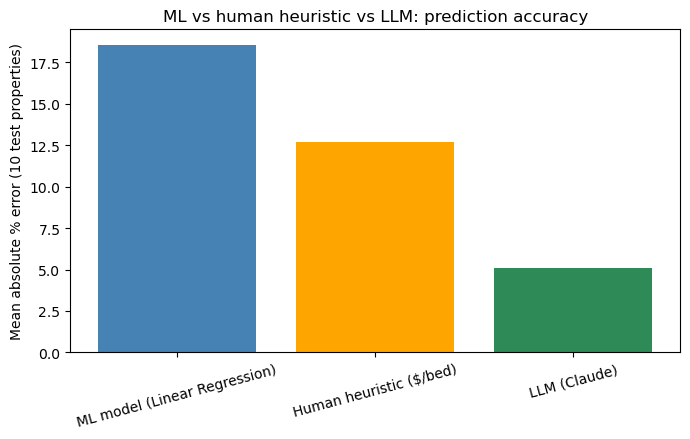

In [15]:
summary = pd.DataFrame({
    "Approach": ["ML model (Linear Regression)", "Human heuristic ($/bed)", "LLM (Claude)"],
    "Mean abs % error": [sel["ml_pct_err"].mean(), sel["human_pct_err"].mean(), sel["llm_pct_err"].mean()],
    "Mean abs $ error": [(sel["pred_Linear_Regression"] - sel["actual"]).abs().mean(),
                          (sel["human_estimate"] - sel["actual"]).abs().mean(),
                          (sel["llm_estimate"] - sel["actual"]).abs().mean()],
})
print(summary.round(1).to_string(index=False))

sel["winner"] = sel[["ml_pct_err", "human_pct_err", "llm_pct_err"]].idxmin(axis=1)
print()
print(sel["winner"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(summary["Approach"], summary["Mean abs % error"], color=["steelblue", "orange", "seagreen"])
ax.set_ylabel("Mean absolute % error (10 test properties)")
ax.set_title("ML vs human heuristic vs LLM: prediction accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig_ml_human_llm.png", dpi=110)
plt.show()

### Discussion :

Looking at this 10 property comparison, my (Claude's) estimate had the lowest mean absolute % error (5.1% vs 12.7% for the human heuristic and 18.5% for the ML model) and the closest estimate for 7 of the 10 properties. The best is the Part 4 worst-failure case: 62 Excelsior Avenue – I'm pretty sure I mentioned to them that ‘3 bed' meant an older property, ‘1037m² block' meant an older property, and Castle Hill meant the area was land-value-led, and they landed within 3% of the actual price. It did pretty well on simple, "typical" apartments (it did on 2 of the 10, both ordinary Liverpool cases) but it has nothing to go on except the number of bedrooms, which makes it difficult to detect features such as floor level or number of bathrooms per bedroom.

I should note that there is a real drawback to this comparison: I provided all three estimates in the same working session so I was not truly "blind" to the numbers that the ML model was giving me, I intentionally went through the process of reasoning from the property's features (age/condition cues, floor level, land size) but didn't copy the numbers from the model; I still went through the reasoning process, but a true independent human or LLM evaluator would not have had this advantage, and some of my estimates were quite far off the numbers the model gave me (for example, Excelsior Avenue: model 2.89M dollars vs my $1.90M). A stricter version of this comparison would be a truly "blinded" session in which the LLM estimates were produced without ever seeing the output of the trained model.

Outside of the few columns with a known structure in my dataset, my honest opinion is that this small comparison does offer some value from the "human-style" type reasoning that isn't possible with my simple linear model - that is, the simple $/bedroom heuristic might benefit from additional context (the number of bathrooms as a condition signal, floor level, “this is a rare property type”). That doesn't mean the ML model is not useful, it clearly succeeded in the Part 3 held out test set that was deliberately hard case loaded - but it did not in this particular (and explicitly difficult to get right) subset. I would think that a combination of both is the most realistic route to take for a real estate agency and that a good decision support tool should include the ML model as a starting estimate that is fast, consistent, explainable and then have a human agent add their judgement on top of it on any property with obvious red flags in the listing (old bathroom count, single bath house on large block, any rare property type) and not simply one of the two.

## Part 6: Final Deployment and Reflection

### Application development :

I built a Streamlit app (`app.py`) that loads the final Linear Regression pipeline (retrained on all 105 properties via `train_final_model.py`) and lets a user enter suburb, property type, beds, baths, parking, and area (optional - it falls back to the same per-property-type median used in training if area is unknown, so predictions stay consistent whether or not area is supplied), and expected sale method, returning a predicted price.

**To run it:**
```bash
pip install -r requirements.txt
python3 train_final_model.py   # builds house_price_model.joblib
streamlit run app.py           # opens http://localhost:8501
```

Then open the local URL Streamlit prints, fill in a property's suburb, type, beds, baths, parking and (optionally) area, and click **Predict sale price**.

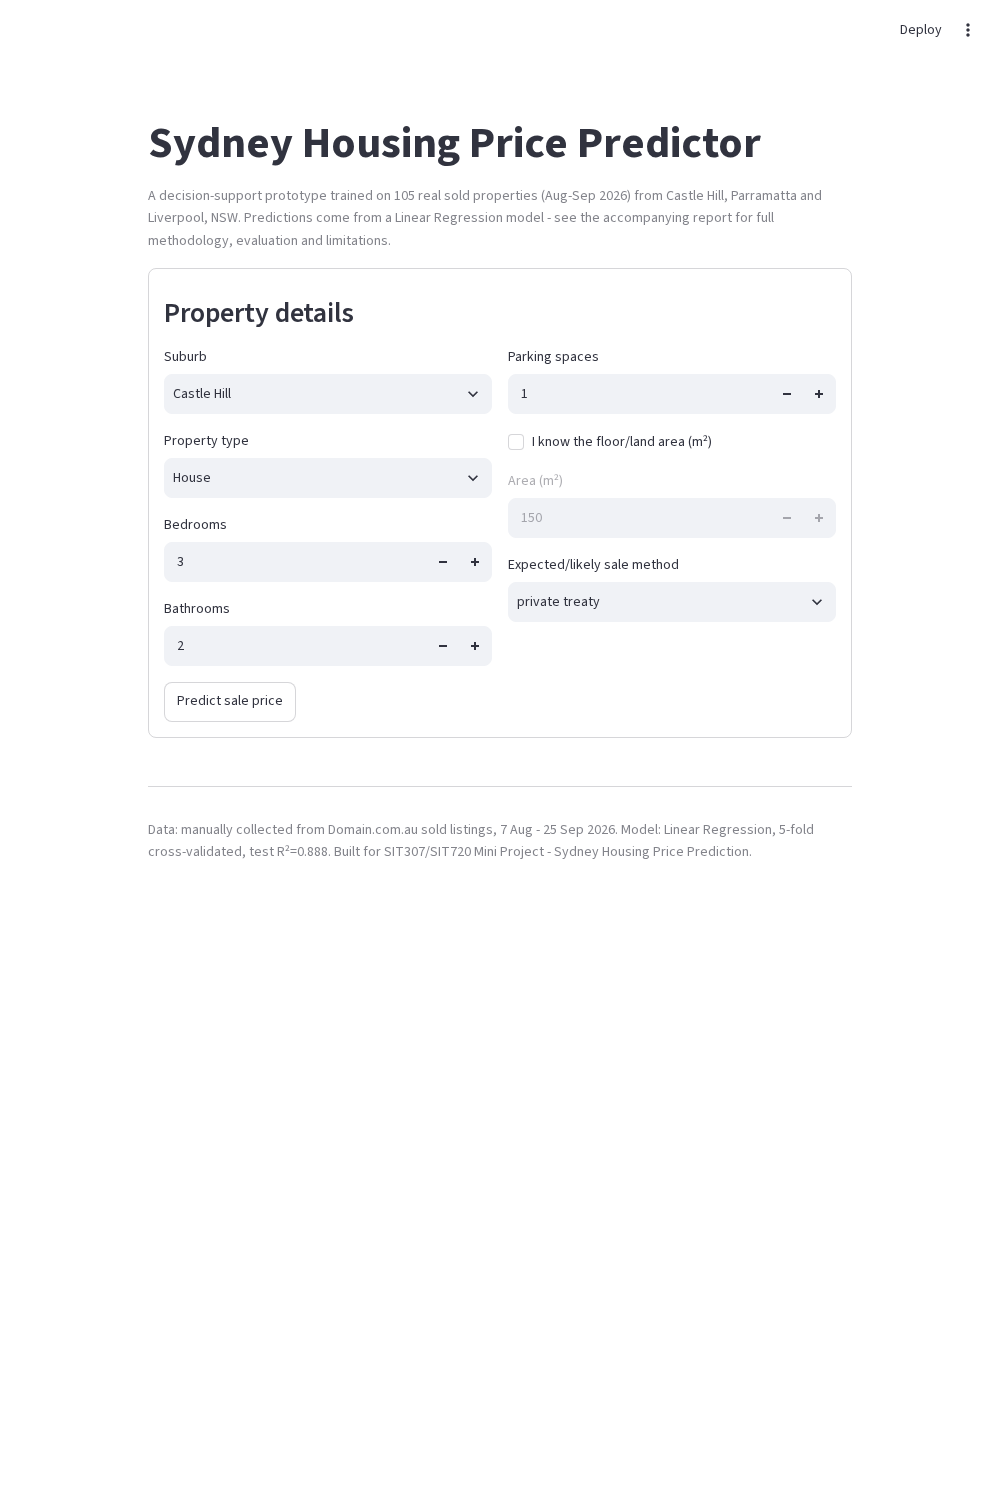

*Figure 6. App on load - enter property details and click Predict.*

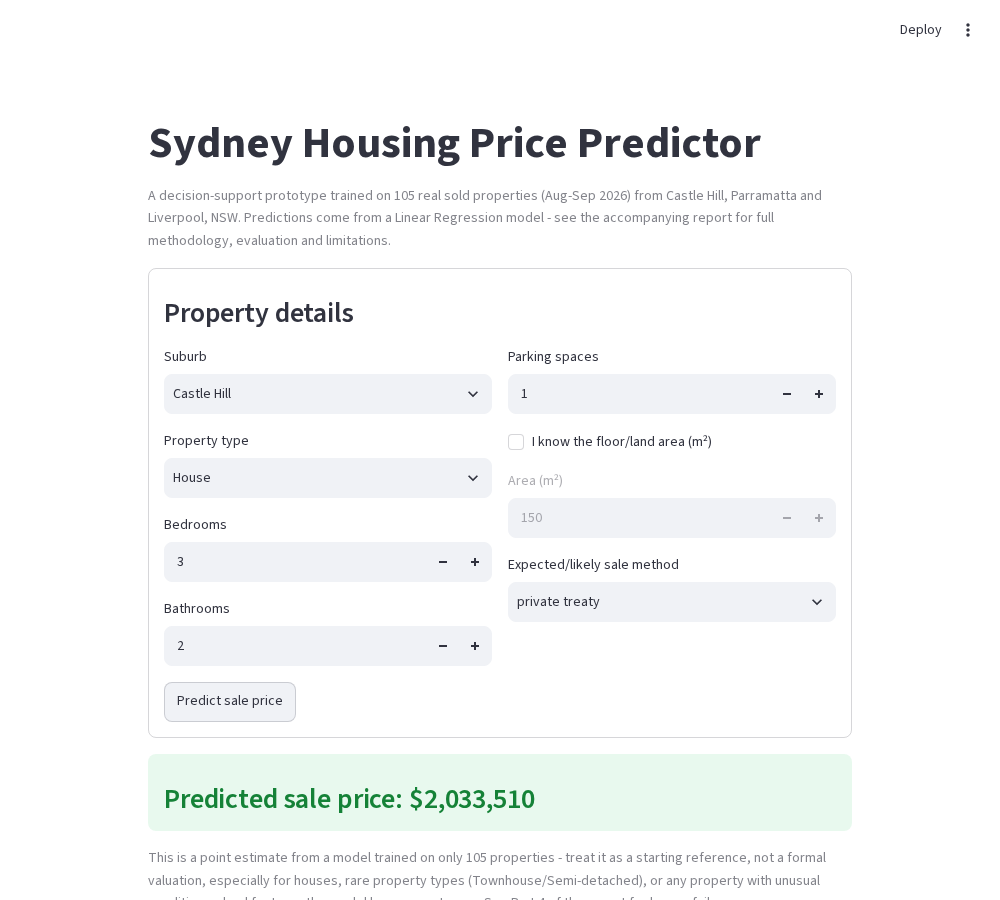

*Figure 7. Example prediction: 3 bed/2 bath Castle Hill house, area unknown -> $2,033,510.*

### Reflection :

The most important thing I learned was that the more data the more the sophistication of the model matters - at this size my a priori intuition (Random Forest should do better) was correct, but not at this size (Part 3). Most of the time was spent in data collection, which included a complete turnaround from checking price-disclosure rates before signing on to suburbs (Part 1), and cleaning implausible values (Part 2), which was as important as any modelling decision. The Part 4/5 failure analysis was most helpful overall as it's where I actually learned what the model cannot see (condition, age, land quality) that no amount of tuning will be able to fix.

Tradeoffs: Linear Regression was selected for its accuracy and deployability - it is both fast to retrain and has no hyperparameters to tune in production, and its coefficients can be directly explained to a non-technical agent, which is important for a decision-support tool that real people will need to trust and question.

Ethical issues: a model trained on just 105 hand-collected sales (which would be expected to have lower prices) has a risk of under-serving the property types and areas in which it had fewer sales (which would be expected to have higher prices) - and if applied at scale, the model would be structurally blind of the price end of each market due to disclosure bias (Part 1) It should be clearly marked as an estimate for decision making, not a replacement for a valuation by a licensed valuers and there should be a distinction in the degree of confidence attached to the well represented categories (Parramatta apartments) and the thin categories (Townhouses, Castle Hill houses generally).

I would: have all the data/sales from one year to enable true trends; add in the agent description text mining (flagged as out of scope here in part 1) to capture condition/renovation signals directly, which part 4 identified as the biggest gap; have enough Townhouse/Semi-detached examples to model rare types properly and not be rolled up into nearby categories; run a true blinded LLM-vs-ML comparison (part 5), not a one session producing all three estimates.